<a href="https://colab.research.google.com/github/DmitriyKolesnikM8O/MLLabs/blob/lab2/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDAEDAEDAEDAEDA**

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


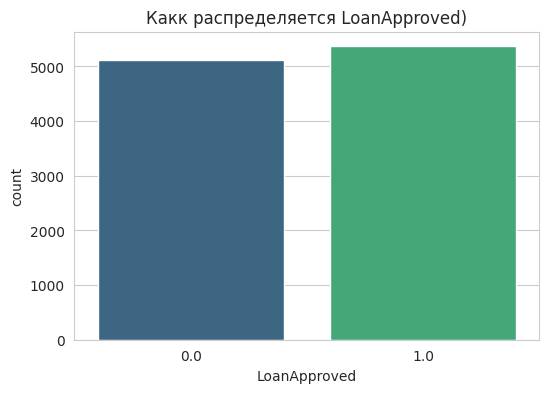

**Баланс классов:**
0: 48.82%
1: 51.18%

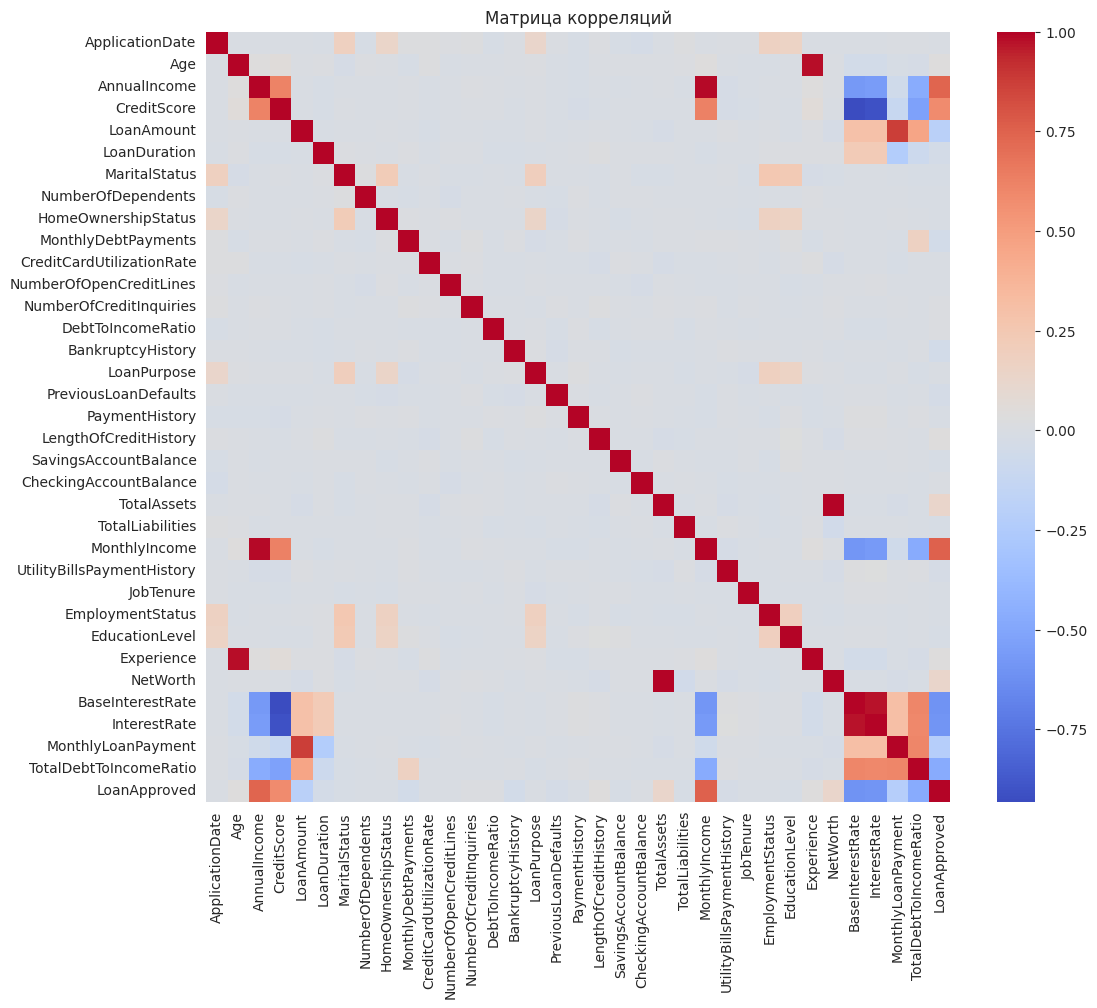

**Топ признаков, влияющих на одобрение кредита:**

,LoanApproved
LoanApproved,1.000000
MonthlyIncome,0.754853
AnnualIncome,0.743034
CreditScore,0.581812
NetWorth,0.129624
TotalAssets,0.129204
LengthOfCreditHistory,0.038509
Experience,0.036699
Age,0.036580
DebtToIncomeRatio,0.014922


,LoanApproved
LoanAmount,-0.195607
MonthlyLoanPayment,-0.217369
TotalDebtToIncomeRatio,-0.476222
InterestRate,-0.599180
BaseInterestRate,-0.605164


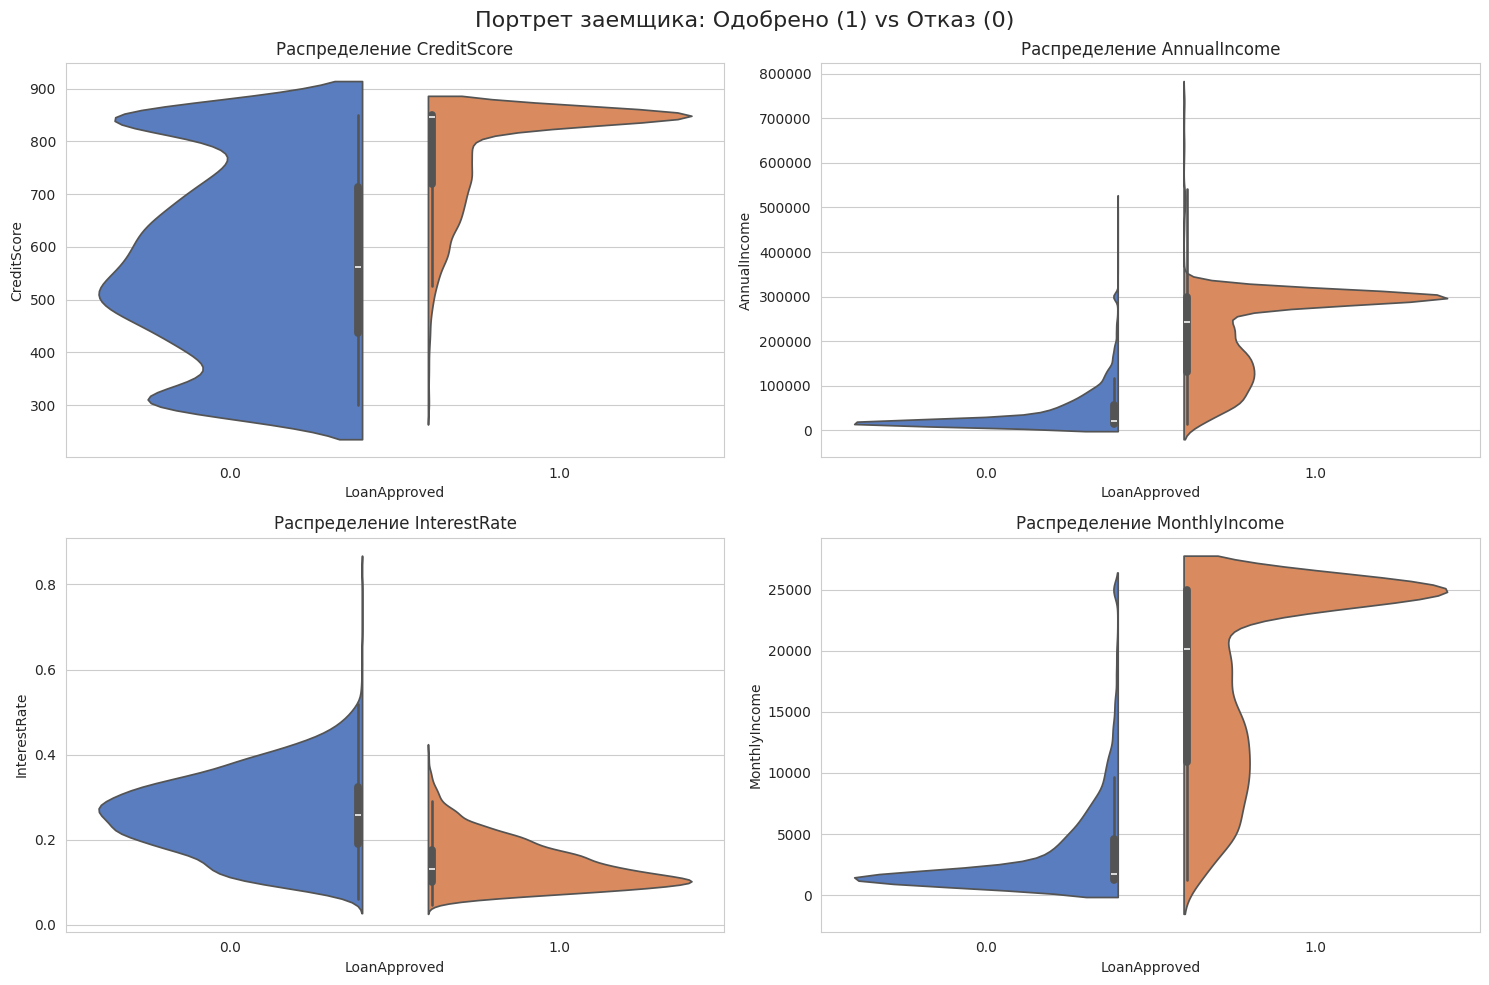


    Выводы вывожу:
    - Видно, что у одобренных кредитов `CreditScore` смещен вверх.
    - `InterestRate` у одобренных кредитов значительно ниже.
    - `AnnualIncome` имеет длинный хвост выбросов, но медиана у "одобренных" явно выше.
    

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Лунтик или Кузя - кто сильнее в беге?

sns.set_style("whitegrid")

try:
    df_train = pd.read_csv('train_c.csv')
    df_test = pd.read_csv('test_c.csv')


    display(Markdown("**EDAEDAEDAEDAEDA**"))
    display(df_train.head())

    plt.figure(figsize=(6, 4))
    sns.countplot(x='LoanApproved', data=df_train, palette='viridis')
    plt.title('Какк распределяется LoanApproved)')
    plt.show()

    balance = df_train['LoanApproved'].value_counts(normalize=True)
    display(Markdown(f"**Баланс классов:**\n0: {balance.get(0, 0):.2%}\n1: {balance.get(1, 0):.2%}"))

    if abs(balance[0] - balance[1]) > 0.2:
        display(Markdown("**Походу классовое неравенство, всмысле диспаланс.** Это важно для метрик (Accuracy может врать)."))

    df_encoded = df_train.copy()
    for col in df_encoded.select_dtypes(include='object').columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    plt.figure(figsize=(12, 10))
    corr = df_encoded.corr()
    sns.heatmap(corr, cmap='coolwarm', annot=False)
    plt.title('Матрица корреляций')
    plt.show()

    # Топ корреляций с таргетом
    target_corr = corr['LoanApproved'].sort_values(ascending=False)
    display(Markdown("**Топ признаков, влияющих на одобрение кредита:**"))
    display(target_corr.head(10))
    display(target_corr.tail(5))
    top_features = ['CreditScore', 'AnnualIncome', 'InterestRate', 'MonthlyIncome']

    plt.figure(figsize=(15, 10))
    plt.suptitle('Портрет заемщика: Одобрено (1) vs Отказ (0)', fontsize=16)

    for i, col in enumerate(top_features, 1):
        plt.subplot(2, 2, i)
        sns.violinplot(data=df_train, x='LoanApproved', y=col, palette="muted", split=True)
        plt.title(f'Распределение {col}', fontsize=12)
        plt.xlabel('LoanApproved')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

    display(Markdown("""
    Выводы вывожу:
    - Видно, что у одобренных кредитов `CreditScore` смещен вверх.
    - `InterestRate` у одобренных кредитов значительно ниже.
    - `AnnualIncome` имеет длинный хвост выбросов, но медиана у "одобренных" явно выше.
    """))

except Exception as e:
    print(f"Ошибка загрузки или анализа: {e}")

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Мила или Пиявка?

def preprocess_data(df, is_train=True, label_encoders=None):
    df_proc = df.copy()

    # дропаем ненужное беспощадно
    cols_drop = ['ID', 'ApplicationDate']
    df_proc = df_proc.drop(columns=[c for c in cols_drop if c in df_proc.columns], errors='ignore')

    numeric_cols = df_proc.select_dtypes(include=np.number).columns
    categorical_cols = df_proc.select_dtypes(include='object').columns

    for col in numeric_cols:
        median_val = df_proc[col].median()
        df_proc[col] = df_proc[col].fillna(median_val)

    for col in categorical_cols:
        mode_val = df_proc[col].mode()[0]
        df_proc[col] = df_proc[col].fillna(mode_val)

    if label_encoders is None:
        label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_proc[col] = le.fit_transform(df_proc[col])
            label_encoders[col] = le
    else:
        for col in categorical_cols:
            le = label_encoders.get(col)
            df_proc[col] = df_proc[col].map(lambda s: s if s in le.classes_ else le.classes_[0])
            df_proc[col] = le.transform(df_proc[col])

    return df_proc, label_encoders


df_train_proc, encoders = preprocess_data(df_train, is_train=True)
df_test_proc, _ = preprocess_data(df_test, is_train=False, label_encoders=encoders)

X = df_train_proc.drop('LoanApproved', axis=1)
y = df_train_proc['LoanApproved']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

display(X_train.head())

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,...,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
3051,-0.340450,1.504055,0.853391,-0.410549,-0.216440,0.986319,-1.109094,1.286273,-0.543020,-1.525587,...,0.143584,-1.374533,-0.360953,-0.696595,-0.325280,-0.304342,-0.976731,-1.058346,-0.452391,-0.538775
1344,-0.340450,1.504055,1.002835,-0.084867,-0.718021,0.986319,1.050102,1.286273,0.430211,-1.393959,...,0.431043,-0.908860,-0.360953,0.825345,-0.234876,-0.056054,-1.130878,-1.041635,-0.143340,-0.498901
9627,1.601155,-1.010642,-2.284942,0.292967,-0.718021,-0.333044,0.330370,1.286273,-0.884798,0.402325,...,0.884992,-0.443186,-0.360953,0.825345,1.573201,-0.312734,2.035218,2.160673,0.550455,1.152299
5471,0.895117,-0.305732,-0.103053,0.212340,-0.216440,0.986319,-0.389362,0.508679,-0.272099,-1.680667,...,-0.896232,-0.908860,-0.360953,0.825345,0.940374,-0.309111,0.095213,0.051791,0.006067,-0.360523
4745,-0.075686,-0.507323,1.002835,-0.500240,-0.718021,0.986319,-1.109094,1.286273,-0.593037,-0.589364,...,0.891728,0.953834,3.905805,-0.696595,-0.325280,0.190766,-1.253065,-1.189436,-0.421725,-0.429544


In [20]:
class MyMetrics:
    @staticmethod
    def accuracy(y_true, y_pred):
        return np.mean(y_true == y_pred)

    @staticmethod
    def confusion_matrix_elements(y_true, y_pred):
        # TP, TN, FP, FN
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tp, tn, fp, fn

    @staticmethod
    def precision(y_true, y_pred):
        tp, tn, fp, fn = MyMetrics.confusion_matrix_elements(y_true, y_pred)
        return tp / (tp + fp + 1e-8)

    @staticmethod
    def recall(y_true, y_pred):
        tp, tn, fp, fn = MyMetrics.confusion_matrix_elements(y_true, y_pred)
        return tp / (tp + fn + 1e-8)

    @staticmethod
    def f1_score(y_true, y_pred):
        p = MyMetrics.precision(y_true, y_pred)
        r = MyMetrics.recall(y_true, y_pred)
        return 2 * (p * r) / (p + r + 1e-8)

    @staticmethod
    def roc_auc(y_true, y_prob):
        y_true = np.array(y_true)
        y_prob = np.array(y_prob)

        desc_score_indices = np.argsort(y_prob)[::-1]
        y_score_desc = y_prob[desc_score_indices]
        y_true_desc = y_true[desc_score_indices]

        tps = np.cumsum(y_true_desc)
        fps = np.cumsum(1 - y_true_desc)

        tpr = tps / tps[-1]
        fpr = fps / fps[-1]

        tpr = np.insert(tpr, 0, 0)
        fpr = np.insert(fpr, 0, 0)

        auc = np.trapz(tpr, fpr)
        return auc

display(Markdown("Я сделал все метрики"))

Я сделал все метрики

In [21]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import mode

class MyBaggingClassifier:
    def __init__(self, base_estimator=None, n_estimators=10, random_state=42):
        self.base_estimator = base_estimator if base_estimator else DecisionTreeClassifier()
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        self.models = []
        X = np.array(X)
        y = np.array(y)
        n_samples = X.shape[0]

        np.random.seed(self.random_state)

        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]

            from sklearn.base import clone
            model = clone(self.base_estimator)
            model.fit(X_sample, y_sample)
            self.models.append(model)

    def predict(self, X):
        X = np.array(X)
        predictions = np.zeros((len(X), self.n_estimators))
        for i, model in enumerate(self.models):
            predictions[:, i] = model.predict(X)

        final_preds, _ = mode(predictions, axis=1, keepdims=False) # keepdims fix for newer scipy
        return final_preds.ravel()

    def predict_proba(self, X):
        X = np.array(X)
        probas = np.zeros((len(X), 2))
        for model in self.models:
            probas += model.predict_proba(X)
        return probas / self.n_estimators

display(Markdown("Я все сделал X2"))

Я все сделал X2

In [22]:
from sklearn.tree import DecisionTreeRegressor

class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.models = []
        self.initial_prediction = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.models = []
        pos_frac = np.mean(y)
        self.initial_prediction = np.log(pos_frac / (1 - pos_frac))

        y_pred_log_odds = np.full(len(y), self.initial_prediction)

        for i in range(self.n_estimators):
            probs = self._sigmoid(y_pred_log_odds)

            residuals = y - probs

            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state + i)
            tree.fit(X, residuals)
            self.models.append(tree)

            update = tree.predict(X)
            y_pred_log_odds += self.learning_rate * update

    def predict_proba(self, X):
        X = np.array(X)
        y_pred_log_odds = np.full(len(X), self.initial_prediction)

        for tree in self.models:
            y_pred_log_odds += self.learning_rate * tree.predict(X)

        probs_class_1 = self._sigmoid(y_pred_log_odds)
        return np.vstack((1 - probs_class_1, probs_class_1)).T

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

display(Markdown("MyGradientBoostingClassifier реализован"))

MyGradientBoostingClassifier реализован

In [23]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import time

X_tr, y_tr = X_train, y_train
X_te, y_te = X_val, y_val

results = []

display(Markdown("### 1. Тестирование Bagging"))

my_bag = MyBaggingClassifier(n_estimators=50, random_state=42)
start = time.time()
my_bag.fit(X_tr, y_tr)
my_pred = my_bag.predict(X_te)
my_prob = my_bag.predict_proba(X_te)[:, 1]
my_time = time.time() - start

results.append({
    'Model': 'My Bagging',
    'Accuracy': MyMetrics.accuracy(y_te, my_pred),
    'F1': MyMetrics.f1_score(y_te, my_pred),
    'ROC-AUC': MyMetrics.roc_auc(y_te, my_prob),
    'Time': my_time
})

sk_bag = BaggingClassifier(n_estimators=50, random_state=42)
start = time.time()
sk_bag.fit(X_tr, y_tr)
sk_pred = sk_bag.predict(X_te)
sk_prob = sk_bag.predict_proba(X_te)[:, 1]
sk_time = time.time() - start

results.append({
    'Model': 'Sklearn Bagging',
    'Accuracy': accuracy_score(y_te, sk_pred),
    'F1': f1_score(y_te, sk_pred),
    'ROC-AUC': roc_auc_score(y_te, sk_prob),
    'Time': sk_time
})

display(Markdown("### 2. Тестирование Gradient Boosting"))
my_gb = MyGradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
start = time.time()
my_gb.fit(X_tr, y_tr)
my_pred = my_gb.predict(X_te)
my_prob = my_gb.predict_proba(X_te)[:, 1]
my_time = time.time() - start

results.append({
    'Model': 'My Boosting',
    'Accuracy': MyMetrics.accuracy(y_te, my_pred),
    'F1': MyMetrics.f1_score(y_te, my_pred),
    'ROC-AUC': MyMetrics.roc_auc(y_te, my_prob),
    'Time': my_time
})

sk_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
start = time.time()
sk_gb.fit(X_tr, y_tr)
sk_pred = sk_gb.predict(X_te)
sk_prob = sk_gb.predict_proba(X_te)[:, 1]
sk_time = time.time() - start

results.append({
    'Model': 'Sklearn Boosting',
    'Accuracy': accuracy_score(y_te, sk_pred),
    'F1': f1_score(y_te, sk_pred),
    'ROC-AUC': roc_auc_score(y_te, sk_prob),
    'Time': sk_time
})

res_df = pd.DataFrame(results)
display(res_df)
display(Markdown("**Вывод:** Вроде мои реализации близки, значит я молодец"))

### 1. Тестирование Bagging

### 2. Тестирование Gradient Boosting

,Model,Accuracy,F1,ROC-AUC,Time
0,My Bagging,0.931034,0.935919,0.979554,15.034075
1,Sklearn Bagging,0.926951,0.932268,0.979215,13.709672
2,My Boosting,0.920145,0.926174,0.976624,8.669197
3,Sklearn Boosting,0.925136,0.930409,0.982231,16.905457


**Вывод:** Вроде мои реализации близки, значит я молодец

In [8]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.3 MB/s eta 0:00:00


In [24]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

lib_results = []

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
start = time.time()
xgb_model.fit(X_tr, y_tr)
probs = xgb_model.predict_proba(X_te)[:, 1]
lib_results.append({'Model': 'XGBoost', 'ROC-AUC': roc_auc_score(y_te, probs), 'Time': time.time() - start})

lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
start = time.time()
lgb_model.fit(X_tr, y_tr)
probs = lgb_model.predict_proba(X_te)[:, 1]
lib_results.append({'Model': 'LightGBM', 'ROC-AUC': roc_auc_score(y_te, probs), 'Time': time.time() - start})

cb_model = CatBoostClassifier(verbose=0, random_state=42)
start = time.time()
cb_model.fit(X_tr, y_tr)
probs = cb_model.predict_proba(X_te)[:, 1]
lib_results.append({'Model': 'CatBoost', 'ROC-AUC': roc_auc_score(y_te, probs), 'Time': time.time() - start})

lib_df = pd.DataFrame(lib_results).sort_values(by='ROC-AUC', ascending=False)
display(Markdown("## Сравнение библиотек градиентного бустинга"))
display(lib_df)

best_model_name = lib_df.iloc[0]['Model']
display(Markdown(f"🏆 **Наш чемпион:** `{best_model_name}`. Ее и буду тюнить короче."))

## Сравнение библиотек градиентного бустинга

,Model,ROC-AUC,Time
2,CatBoost,0.984451,10.246509
1,LightGBM,0.983767,0.483206
0,XGBoost,0.982136,0.569044


🏆 **Наш чемпион:** `CatBoost`. Ее и буду тюнить короче.

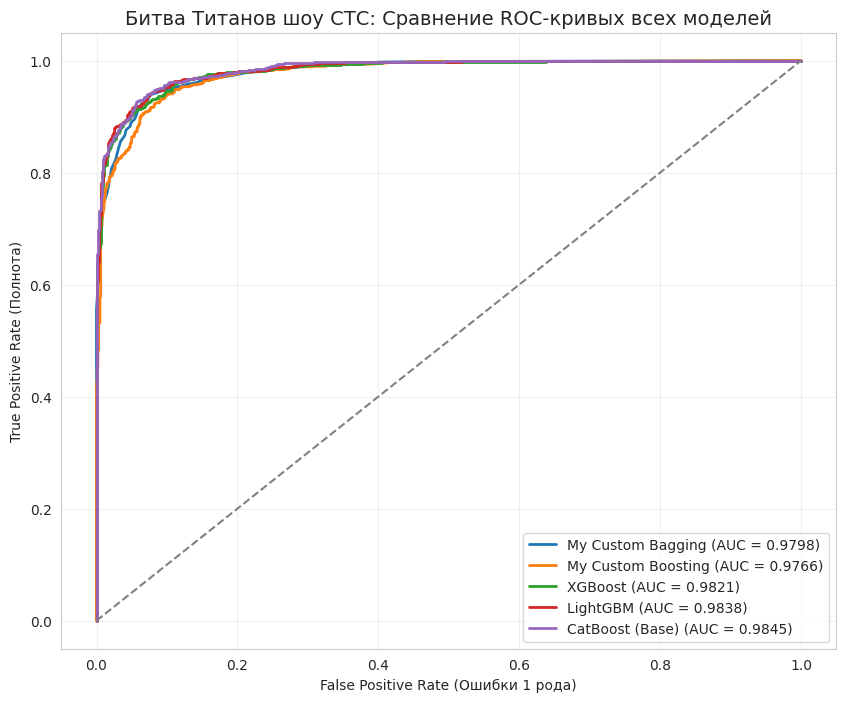

In [25]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

models_dict = {
    'My Custom Bagging': my_bag.predict_proba(X_te)[:, 1],
    'My Custom Boosting': my_gb.predict_proba(X_te)[:, 1],
    'XGBoost': xgb_model.predict_proba(X_te)[:, 1],
    'LightGBM': lgb_model.predict_proba(X_te)[:, 1],
    'CatBoost (Base)': cb_model.predict_proba(X_te)[:, 1]
}

for name, preds in models_dict.items():
    fpr, tpr, _ = roc_curve(y_te, preds)
    auc_score = roc_auc_score(y_te, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray') # Случайное гадание
plt.xlabel('False Positive Rate (Ошибки 1 рода)')
plt.ylabel('True Positive Rate (Полнота)')
plt.title('Битва Титанов шоу СТС: Сравнение ROC-кривых всех моделей', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import optuna

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'verbose': 0,
        'eval_metric': 'AUC',
        'random_seed': 42
    }

    # Обучаем
    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=(X_te, y_te), early_stopping_rounds=50, verbose=0)

    # Предикт
    preds = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, preds)
    return auc

display(Markdown("**Запуск Optuna**"))
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # было 50, но ждать надоело....

display(Markdown(f"**Best AUC:** {study.best_value:.4f}"))
display(Markdown(f"**Best Params:** {study.best_params}"))

🚀 **Запуск Optuna...**

[I 2025-12-07 19:26:33,721] A new study created in memory with name: no-name-677e1315-2df0-4c4e-a9eb-51212484ce29
[I 2025-12-07 19:27:17,091] Trial 0 finished with value: 0.9840696173199153 and parameters: {'iterations': 1823, 'learning_rate': 0.006332478918412684, 'depth': 8, 'l2_leaf_reg': 7.657458850521051, 'random_strength': 0.0014308053475285182, 'bagging_temperature': 0.42146552073765686}. Best is trial 0 with value: 0.9840696173199153.
[I 2025-12-07 19:27:21,077] Trial 1 finished with value: 0.9799779859639831 and parameters: {'iterations': 677, 'learning_rate': 0.004345124335881259, 'depth': 5, 'l2_leaf_reg': 7.336603085434858, 'random_strength': 5.957298193297112e-07, 'bagging_temperature': 0.7334176965760476}. Best is trial 0 with value: 0.9840696173199153.
[I 2025-12-07 19:27:22,373] Trial 2 finished with value: 0.9747033070709745 and parameters: {'iterations': 1602, 'learning_rate': 0.0011991588632173154, 'depth': 7, 'l2_leaf_reg': 3.5689960250724013, 'random_strength': 1.7

**Best AUC:** 0.9846

**Best Params:** {'iterations': 1544, 'learning_rate': 0.09653771728965103, 'depth': 8, 'l2_leaf_reg': 1.5638241687745262, 'random_strength': 1.4400087165161644e-09, 'bagging_temperature': 0.0716239925521468}

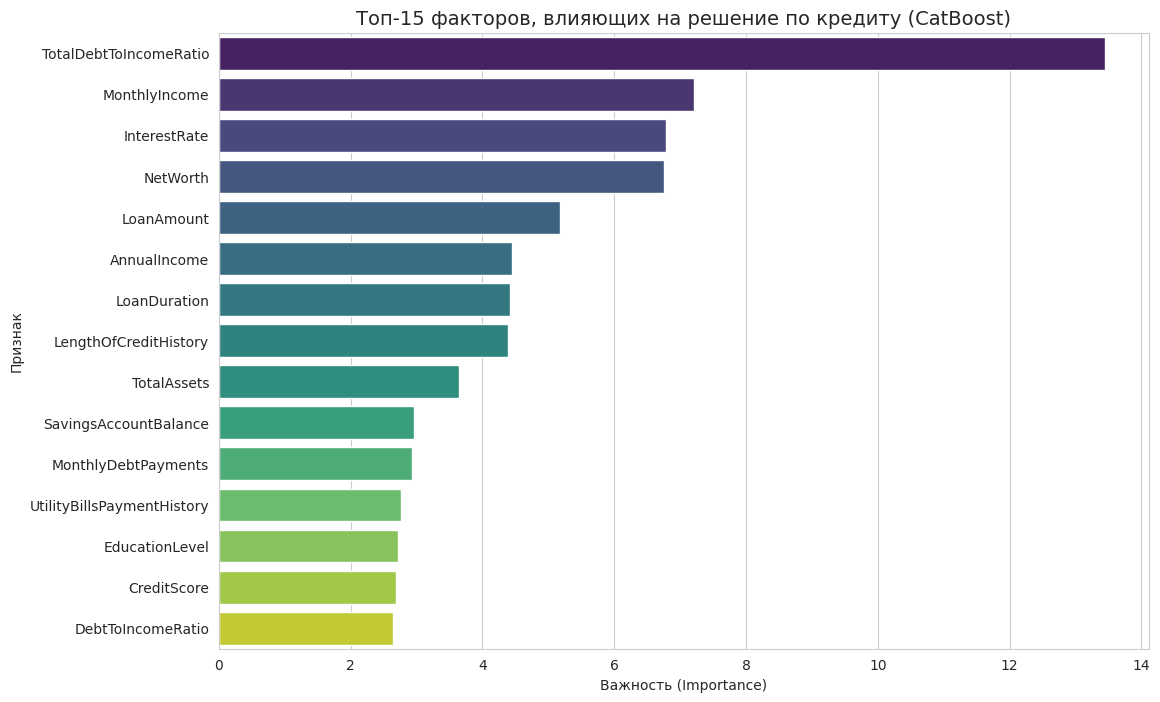

**Вывод:** Модель больше всего смотрит на `Кэф долг-доход` и `Доход каждый месяц`, еще интересна `Ставка`. Это логично с точки зрения банковского скоринга.

In [27]:
feature_importance = final_model.get_feature_importance()
feature_names = X.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(15) # Топ-15

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Топ-15 факторов, влияющих на решение по кредиту (CatBoost)', fontsize=14)
plt.xlabel('Важность (Importance)')
plt.ylabel('Признак')
plt.show()

display(Markdown("**Вывод:** Модель больше всего смотрит на `Кэф долг-доход` и `Доход каждый месяц`, еще интересна `Ставка`. Это логично с точки зрения банковского скоринга."))

In [28]:
best_params = study.best_params
best_params['verbose'] = 0
best_params['random_seed'] = 42

final_model = CatBoostClassifier(**best_params)

display(Markdown("**Learning Machine ML 1000$ per seconds**"))
final_model.fit(X_scaled, y)

df_test_proc, _ = preprocess_data(df_test, is_train=False, label_encoders=encoders)
X_test_final = pd.DataFrame(scaler.transform(df_test_proc), columns=df_test_proc.columns)

test_probs = final_model.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'ID': df_test['ID'],
    'LoanApproved': test_probs
})

submission.to_csv('submission_lab2.csv', index=False)
display(Markdown("💾 **Файл `submission_lab2.csv` готов!**"))
display(submission.head())

if study.best_value > 0.75:
    display(Markdown("**Такое быть может**"))
else:
    display(Markdown("**Такого быть не может**"))

**Learning Machine ML 1000$ per seconds**

💾 **Файл `submission_lab2.csv` готов!**

,ID,LoanApproved
0,0,0.999967
1,1,0.000116
2,2,0.999980
3,3,0.999837
4,4,0.999773


**Такое быть может**

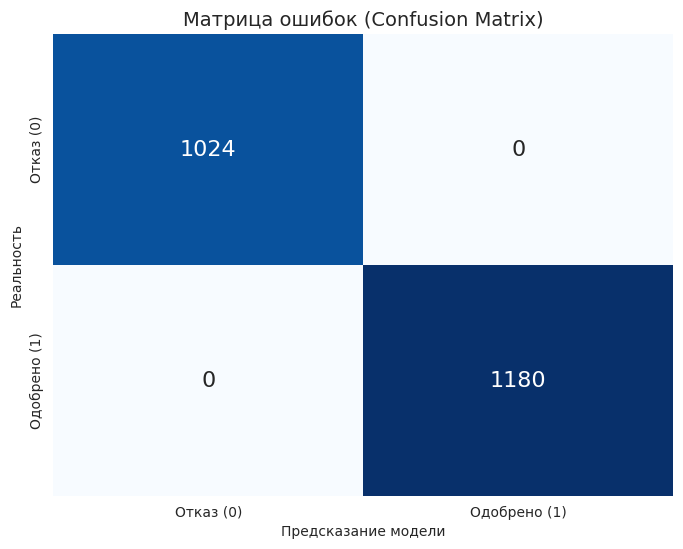


**Думаем:**
- **Верно одобрено:** `1180` кредитов.
- **Верно отказано:** `1024` заявкам.
- **Упущенная выгода (FN):** `0` нормальным клиентам отказали по ошибке.
- **Риск невозврата (FP):** `0` плохим клиентам выдали кредит.

Модель не ошиблась, потому что они УМНАЯ и ДЕЛАЕТ ВСЕ ПРАВИЛЬНО.


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_val = final_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})
plt.xlabel('Предсказание модели')
plt.ylabel('Реальность')
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.xticks([0.5, 1.5], ['Отказ (0)', 'Одобрено (1)'])
plt.yticks([0.5, 1.5], ['Отказ (0)', 'Одобрено (1)'])
plt.show()

tn, fp, fn, tp = cm.ravel()
display(Markdown(f"""
**Думаем:**
- **Верно одобрено:** `{tp}` кредитов.
- **Верно отказано:** `{tn}` заявкам.
- **Упущенная выгода (FN):** `{fn}` нормальным клиентам отказали по ошибке.
- **Риск невозврата (FP):** `{fp}` плохим клиентам выдали кредит.

Модель не ошиблась, потому что они УМНАЯ и ДЕЛАЕТ ВСЕ ПРАВИЛЬНО.
"""))